## **Figure-S14**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

import seaborn as sns
sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


---

---

In [3]:
# Use default mpl color cycle
default_colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']


In [4]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based') # need to adjust format_for_plot method as well

In [5]:
condition_palette_extended = {
    condition['orig']: default_colors[0],
    condition['refined'] + '_5ngLib': "#FFB77E",
    condition['refined'] + '_25ngLib': "#FF7F0E",   # Lightest Orange
    condition['refined'] + '_100ngLib' :  '#B85B00'  # Darkest Orange
}


In [6]:

condition_palette = {
    condition['orig']: default_colors[0],
    condition['refined']: default_colors[1],
}

In [7]:
def format_for_plot(rslts, condition_palette_extended=condition_palette_extended):
    ids = pd.DataFrame(rslts).map(lambda x: len(x) if isinstance(x, set) else np.nan ).melt(var_name='Library', value_name='# Proteins', ignore_index=False).reset_index(names='FullCondition').dropna()
    ids['Condition'] = ids["FullCondition"].str.replace(r"^(Reference-based).*", r"\1", regex=True)
    
    
    # create normalized Ids
    expWorkflowIds = ids[(ids['Library'] == names['exp']) & (ids['Condition'] == condition['orig'])]['# Proteins'].values[0]
    idsNorm = ids.copy()
    idsNorm['# Proteins'] = (idsNorm['# Proteins'].astype('float64') / expWorkflowIds)
    
    #combine
    ids['Normalized # Proteins'] = idsNorm['# Proteins']
    ids["point_color"] = ids["FullCondition"].map(condition_palette_extended)

    return ids


#### **Load Data**

In [8]:
diann = { n:defaultdict(dict) for n in names.values() }
osw = { n:defaultdict(dict) for n in names.values() }

##### **DIA-NN Results**

In [9]:
# Bruker data
diann[names['bruker']][condition['orig']] = getProteinSetDiann("../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['bruker']][condition['refined'] + '_25ngLib'] = getProteinSetDiann("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/25ng_lib/report.tsv")
diann[names['bruker']][condition['refined'] + '_5ngLib'] = getProteinSetDiann("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/5ng_lib/report.tsv")
diann[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSetDiann("../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/100ng_lib/report.tsv")


# Silico data
diann[names['silico']][condition['orig']] = getProteinSetDiann("../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['silico']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/25ng_lib/report.tsv")
diann[names['silico']][condition['refined'] + '_5ngLib' ] = getProteinSetDiann("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/5ng_lib/report.tsv")
diann[names['silico']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/100ng_lib/report.tsv")


# DiaTracer data
diann[names['diatracer']][condition['orig']] = getProteinSetDiann("../../results/Dilutions-diaTracer/diann/1ng/report.tsv")
diann[names['diatracer']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/100ng_lib/report.tsv")
diann[names['diatracer']][condition['refined'] + '_5ngLib' ] = getProteinSetDiann("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/5ng_lib/report.tsv")
diann[names['diatracer']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann("../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/25ng_lib/report.tsv")


# Experimental data
diann[names['exp']][condition['orig']] = getProteinSetDiann("../../results/Dilutions-K562-Exp-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['exp']][condition['refined'] + '_25ngLib' ] = getProteinSetDiann("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined'] + '_5ngLib' ] = getProteinSetDiann("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/5ng_lib/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['refined'] + '_100ngLib' ] = getProteinSetDiann("../../results/Dilutions-Exp-Refined-Analysis/diann/1ng/100ng_lib/report.tsv", infer_schema_length=1000)



# PanHuman data
diann[names['panhuman']][condition['orig']] = getProteinSetDiann("../../results/Dilutions-K562-PanHuman-Library/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv")
diann[names['panhuman']][condition['refined'] + '_25ngLib'] = getProteinSetDiann("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/25ng_lib/report.tsv", infer_schema_length=1000)
diann[names['panhuman']][condition['refined'] + '_5ngLib'] = getProteinSetDiann("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/5ng_lib/report.tsv", infer_schema_length=1000)
diann[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSetDiann("../../results/Dilutions-PanHuman-Refined-Analysis/diann/1ng/100ng_lib/report.tsv", infer_schema_length=1000)

../../results/Dilutions-K562-Bruker-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv
../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/25ng_lib/report.tsv
../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/5ng_lib/report.tsv
../../results/Dilutions-Bruker-Refined-Analysis/diann/1ng/100ng_lib/report.tsv
../../results/Dilutions-PeptDeep-NoMods-Lib/diann/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/report.tsv
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/25ng_lib/report.tsv
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/5ng_lib/report.tsv
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/diann/1ng/100ng_lib/report.tsv
../../results/Dilutions-diaTracer/diann/1ng/report.tsv
../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/100ng_lib/report.tsv
../../results/Dilutions-K562-diaTracer-Refinement/diann/1ng/5ng_lib/report.tsv
../../results/Dilutions-K562-diaTracer-Refinement/diann

#### **OSW Results**

In [10]:
# Bruker data
osw[names['bruker']][condition['orig']] = getProteinSet_oswpq("../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_25ngLib'] = getProteinSet_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_5ngLib'] = getProteinSet_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['bruker']][condition['refined'] + '_100ngLib'] = getProteinSet_oswpq("../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")


# Silico data
osw[names['silico']][condition['orig']] = getProteinSet_oswpq("../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_25ngLib'] = getProteinSet_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_5ngLib'] = getProteinSet_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['silico']][condition['refined'] + '_100ngLib'] = getProteinSet_oswpq("../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")



# DiaTracer data
osw[names['diatracer']][condition['orig']] = getProteinSet("../../results/Dilutions-diaTracer/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_LDA/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw[names['diatracer']][condition['refined'] + '_25ngLib'] = getProteinSet("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/25ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw[names['diatracer']][condition['refined'] + '_5ngLib'] = getProteinSet("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/5ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")
osw[names['diatracer']][condition['refined'] + '_100ngLib'] = getProteinSet("../../results/Dilutions-K562-diaTracer-Refinement/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/100ng_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.parquet")


# Experimental data
osw[names['exp']][condition['orig']] = getProteinSet_oswpq("../../results/Dilutions-K562-Exp-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['exp']][condition['refined'] + '_25ngLib'] = getProteinSet_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['exp']][condition['refined'] + '_5ngLib'] = getProteinSet_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")
osw[names['exp']][condition['refined'] + '_100ngLib'] = getProteinSet_oswpq("../../results/Dilutions-Exp-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq")


# PanHuman data
osw[names['panhuman']][condition['orig']] = getProteinSet_oswpq("../../results/Dilutions-K562-PanHuman-Library/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_25ngLib'] = getProteinSet_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_5ngLib'] = getProteinSet_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")
osw[names['panhuman']][condition['refined'] + '_100ngLib'] = getProteinSet_oswpq("../../results/Dilutions-PanHuman-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/")

../../results/Dilutions-K562-Bruker-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_5_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-Bruker-Refined-Analysis/osw/1ng/1ng_100_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq
../../results/Dilutions-PeptDeep-NoMods-Lib/osw/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021/pyprophet_SVM/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDeepNoMods-Refined-Analysis/osw/1ng/1ng_25_lib/pyprophet_XGB/90min-SP-30cm-2um-K562-100nL-1ng_DIA_Slot1-4_1_552_3-8-2021.oswpq/
../../results/Dilutions-PeptDe

#### **Format For Plot**

In [11]:
ids_diann = format_for_plot(diann)
ids_osw = format_for_plot(osw)

In [12]:
np.random.seed(40)
def plotIDs(data, ax, title, show_xlabel=False, font_size_small=9, font_size_medium=10, font_size_large=11, ):    
    # Updated kwargs with better error bar color
    kwargs = dict(estimator='median', palette=condition_palette, errorbar=None, 
                  edgecolor="white", alpha=0.5)
    # Absolute values (left axis)
    sns.barplot(
        data=data,
        x="Library", y="# Proteins", hue="Condition", ax=ax, legend=False, **kwargs)

    sns.swarmplot(data=data, x='Library', y='# Proteins', hue='Condition', ax=ax, 
                  legend=False, palette=condition_palette, dodge=True, s=6, 
                  linewidth=1, edgecolor='black')
    
    
    # recolor swarm points using FullCondition palette
    collections = ax.collections[-len(data["Library"].unique()) * len(data["Condition"].unique()):]

    grouped = data.groupby(["Library", "Condition"], sort=False)

    for coll, ((lib, cond), subset) in zip(collections, grouped):
        colors = subset["point_color"].values
        coll.set_facecolors(colors)
    ax.set_ylabel("# Proteins", fontsize=font_size_large)
    if not show_xlabel:
        ax.set_xticks([])
        ax.set_xlabel("")
        ax.tick_params(labelsize=font_size_small)
    else:
        ax.set_xlabel("Library", fontsize=font_size_large)
        ax.tick_params('x', labelsize=font_size_small, rotation=30)
        for l in ax.get_xticklabels():
            if l.get_text() == 'in-silico':
                l.set_fontstyle('italic')

    ax.tick_params('y', labelsize=font_size_small)
    
    ax.set_title(title, fontsize=font_size_large)
    ax.grid(True, axis="y", alpha=0.3, zorder=-2)
    ax.set_ylim(0, 4500)
  

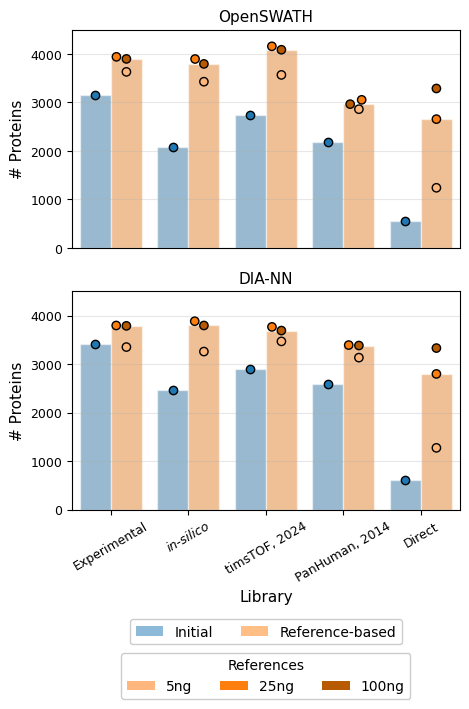

In [13]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(5, 6))
plotIDs(ids_osw, title='OpenSWATH', ax=ax1, show_xlabel=False)
plotIDs(ids_diann, title='DIA-NN', ax=ax2, show_xlabel=True)
# Custom legend (one per condition) - placed at bottom
handles = [
        plt.matplotlib.patches.Patch(facecolor=condition_palette[c], label=c, alpha=0.5)
        for c in ids_diann['Condition'].unique()
    ]
leg = ax2.legend(handles=handles, loc='lower center', ncol=len(handles),
               fontsize=10, facecolor='white', framealpha=1, 
               bbox_to_anchor=(0.5, -0.65))
ax2.add_artist(leg)

handles2 = [
    plt.matplotlib.patches.Patch(facecolor="#FFB77E", label='5ng'),
    plt.matplotlib.patches.Patch(facecolor="#FF7F0E", label='25ng'),
    plt.matplotlib.patches.Patch(facecolor="#B85B00", label='100ng')
]

ax2.legend(handles=handles2, labels=[f'{i}ng' for i in [5, 25, 100] ], loc='lower center', ncol=len(handles2),
               fontsize=10, facecolor='white', framealpha=1, title='References', title_fontsize=10,
               bbox_to_anchor=(0.5, -0.9))

plt.subplots_adjust(bottom=0.08)  # Make room for the legend
plt.savefig('Figure-S14.png', dpi=300, bbox_inches='tight')
